# Pedestrian Count Analysis — Spencer Street vs William Street

**Author:** Pavan Naganityaa Santosh Reddy Punuru

**Datasets used:**
1. **Pedestrian Counting System (counts per hour)** — City of Melbourne / Transport Victoria open data
   Source: https://discover.data.vic.gov.au/dataset/pedestrian-counting-system-counts-per-hour
2. **sites_db.csv** — PO-provided site/intervention reference data (control vs intervention classification, parking capacity, bike lane status over time)
3. **street_segment_qtr_attributes.csv** — PO-provided quarterly street segment attributes (construction periods)

**Comparison:** Spencer St (Control) vs William St (Protected Bike Lane)s .


## 1. Setup

In [2]:
!pip install contextily geopandas -q

In [3]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as ctx

pd.set_option('display.max_columns', 50)


## 2. Data Loading

Loading both the pedestrian sensor data and the two PO-provided reference files.


In [4]:
# Pedestrian Counting System (hourly counts)
ped = pd.read_csv("pedestrian-counting-system-monthly-counts-per-hour.csv")

# PO-provided site/intervention reference data
sites_db = pd.read_csv("sites_db.csv", encoding='latin1')
street_segment_qtr = pd.read_csv("street_segment_qtr_attributes.csv", encoding='latin1')

print("Pedestrian data shape:", ped.shape)
print("sites_db shape:", sites_db.shape)
print("street_segment_qtr shape:", street_segment_qtr.shape)


Pedestrian data shape: (1613233, 9)
sites_db shape: (637, 35)
street_segment_qtr shape: (30783, 15)


In [5]:
ped.head()

,id,location_id,sensing_date,hourday,direction_1,direction_2,pedestriancount,sensor_name,location
0,143320260803,143,2026-08-03,3,7,4,11,Spencer_T,"-37.821728, 144.95557015"
1,59220260803,59,2026-08-03,2,23,14,37,RMIT_T,"-37.80825648, 144.96304859"
2,69120260803,69,2026-08-03,1,2,4,6,FLDegC_T,"-37.81687226, 144.96559144"
3,161320260803,161,2026-08-03,3,2,1,3,BirArt1109_T,"-37.81851276, 144.97131336"
4,75320260803,75,2026-08-03,3,1,1,2,SprFli_T,"-37.81515276, 144.97467661"


## 3. Data Processing

Checking for nulls and converting the date column, the same first steps used across the team's other pedestrian notebooks.


In [6]:
print(ped.isna().sum())


id                     0
location_id            0
sensing_date           0
hourday                0
direction_1            0
direction_2            0
pedestriancount        0
sensor_name        25593
location           25593
dtype: int64


In [7]:
ped_clean = ped[ped['sensor_name'].notna()].copy()
ped_clean['sensing_date'] = pd.to_datetime(ped_clean['sensing_date'], errors='coerce')
ped_clean['month'] = ped_clean['sensing_date'].dt.to_period('M')
ped_clean['day_of_week'] = ped_clean['sensing_date'].dt.day_name()

print(ped_clean.shape)


(1587640, 11)


## 4. Identifying Spencer St and William St Sensors



In [8]:
spencer_candidates = ped_clean[ped_clean['sensor_name'].str.contains("Spen", case=False, na=False)]['location_id'].unique()
william_candidates = ped_clean[ped_clean['sensor_name'].str.contains("Will", case=False, na=False)]['location_id'].unique()

print("Spencer St candidate location_ids:", list(spencer_candidates))
print("William St candidate location_ids:", list(william_candidates))


Spencer St candidate location_ids: [np.int64(143), np.int64(165), np.int64(134), np.int64(135), np.int64(133), np.int64(166)]
William St candidate location_ids: [np.int64(109), np.int64(107), np.int64(108)]


In [9]:
candidates = {
    143: "Spencer_T", 165: "Spen475_T", 134: "Spen201_T",
    135: "Spen161_T", 133: "Spen229_T", 166: "Spen484_T",
    109: "LatWill_T", 107: "280Will_T", 108: "261Will_T",
}

df = ped_clean[ped_clean['location_id'].isin(candidates.keys())].copy()
df['street'] = df['sensor_name'].apply(lambda n: 'William St' if 'Will' in n else 'Spencer St')
print(df['street'].value_counts())


street
Spencer St    101436
William St     51812
Name: count, dtype: int64


## 5. Sensor Location Map

Confirming each candidate sensor genuinely sits on its named street, using real coordinates.


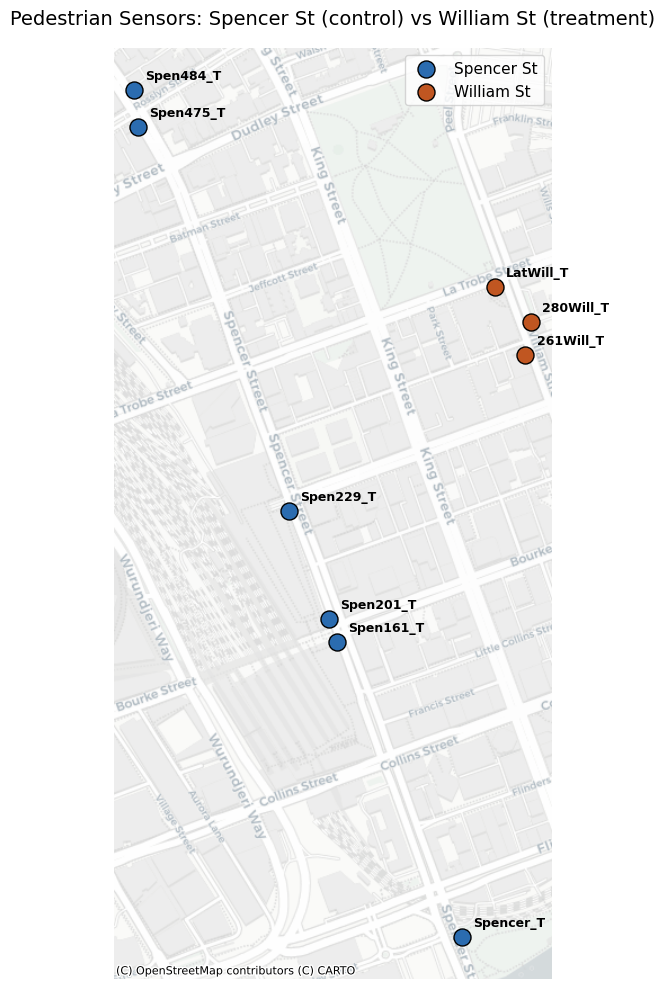

In [11]:
locs = df[['location_id','sensor_name','location','street']].drop_duplicates(subset=['location_id'])
locs['lat'] = locs['location'].str.split(',').str[0].astype(float)
locs['lon'] = locs['location'].str.split(',').str[1].astype(float)

gdf = gpd.GeoDataFrame(locs, geometry=gpd.points_from_xy(locs['lon'], locs['lat']), crs="EPSG:4326")
gdf_web = gdf.to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(10, 10))
colors = {'Spencer St': '#2b6cb0', 'William St': '#c05621'}
for street, color in colors.items():
    subset = gdf_web[gdf_web['street'] == street]
    subset.plot(ax=ax, color=color, markersize=150, edgecolor='black', label=street, zorder=3)

for x, y, label in zip(gdf_web.geometry.x, gdf_web.geometry.y, gdf_web['sensor_name']):
    ax.annotate(label, (x, y), textcoords="offset points", xytext=(8, 8), fontsize=9, weight='bold')

ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)
ax.set_title("Pedestrian Sensors: Spencer St (control) vs William St (treatment)", fontsize=14)
ax.legend(fontsize=11)
ax.set_axis_off()
plt.tight_layout()
plt.savefig("spencer_william_map.png", dpi=150)
plt.show()


## 6. Data Coverage Check

Before running any comparison, checking how much history each sensor actually has.


In [12]:
coverage = df.groupby(['location_id','sensor_name'])['sensing_date'].agg(['min','max','count']).reset_index()
coverage.columns = ['location_id','sensor_name','first_date','last_date','num_records']
print(coverage.to_string(index=False))


 location_id sensor_name first_date  last_date  num_records
         107   280Will_T 2024-08-04 2026-08-03        17443
         108   261Will_T 2024-08-04 2026-07-08        16886
         109   LatWill_T 2024-08-04 2026-08-03        17483
         133   Spen229_T 2024-08-04 2026-08-03        17428
         134   Spen201_T 2024-08-04 2026-08-03        17481
         135   Spen161_T 2024-08-04 2026-08-03        17493
         143   Spencer_T 2024-08-04 2026-08-03        17315
         165   Spen475_T 2024-08-14 2026-08-03        16406
         166   Spen484_T 2024-09-25 2026-08-03        15313


**Key finding:** every sensor's data starts around **August 2024**. This is a hard limit of the currently downloaded file, not specific to Spencer/William St; the same pattern was found across the whole dataset.


## 7. Pedestrian Activity Comparison (current data window)

Since a true before/after isn't possible with this file (see Section 6 and Section 9), the following compares current pedestrian activity between the two streets across the available Aug 2024 – Aug 2026 window.


In [13]:
summary = df.groupby('street')['pedestriancount'].agg(['mean','median','std']).round(1)
print(summary)


             mean  median    std
street                          
Spencer St  349.1   157.0  377.0
William St  259.6   171.0  348.6


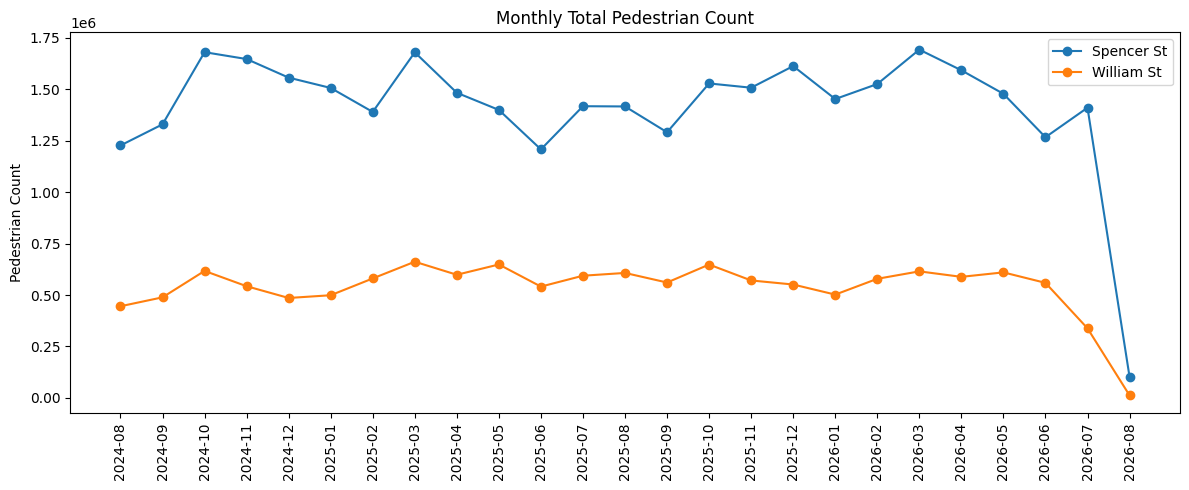

In [14]:
monthly = df.groupby(['street', df['month'].astype(str)])['pedestriancount'].sum().reset_index()
monthly.columns = ['street','month','pedestriancount']

plt.figure(figsize=(12,5))
for street in ['Spencer St','William St']:
    sub = monthly[monthly['street']==street]
    plt.plot(sub['month'], sub['pedestriancount'], marker='o', label=street)
plt.xticks(rotation=90)
plt.title("Monthly Total Pedestrian Count")
plt.ylabel("Pedestrian Count")
plt.legend()
plt.tight_layout()
plt.show()


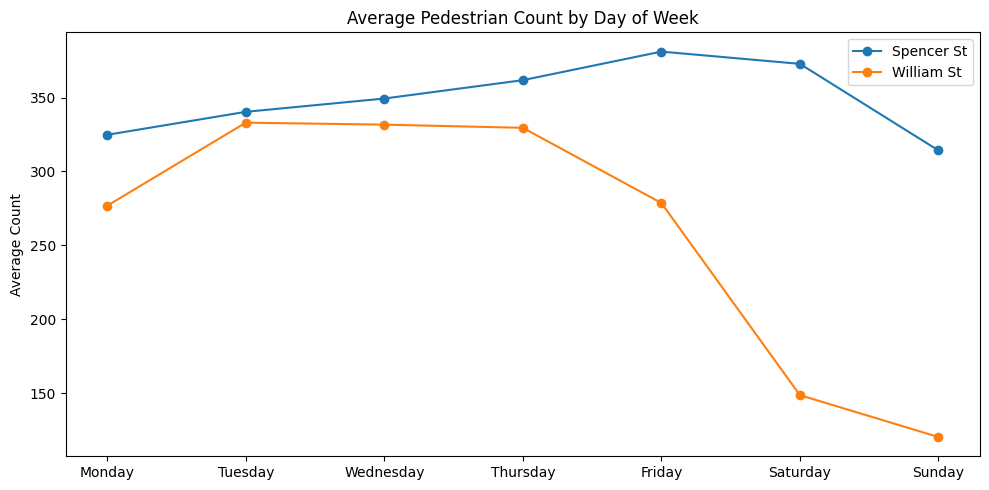

street       Spencer St  William St
day_of_week                        
Monday       324.793632  276.814415
Tuesday      340.332521  333.013389
Wednesday    349.337030  331.671856
Thursday     361.756888  329.522340
Friday       381.086948  278.653534
Saturday     372.792234  148.657468
Sunday       314.222222  120.329311


In [15]:
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow = df.groupby(['street','day_of_week'])['pedestriancount'].mean().reset_index()
dow['day_of_week'] = pd.Categorical(dow['day_of_week'], categories=day_order, ordered=True)
dow = dow.sort_values('day_of_week')

plt.figure(figsize=(10,5))
for street in ['Spencer St','William St']:
    sub = dow[dow['street']==street]
    plt.plot(sub['day_of_week'], sub['pedestriancount'], marker='o', label=street)
plt.title("Average Pedestrian Count by Day of Week")
plt.ylabel("Average Count")
plt.legend()
plt.tight_layout()
plt.show()

print(dow.pivot(index='day_of_week', columns='street', values='pedestriancount').reindex(day_order))


**Key finding:** Spencer St stays busy through the weekend (Saturday nearly as busy as weekdays), while William St drops by more than half on Saturday and two-thirds on Sunday .


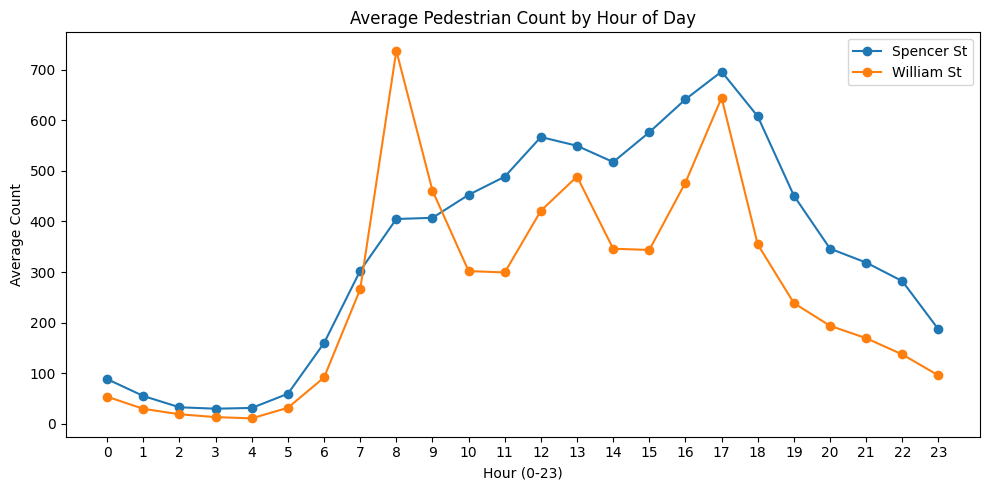

In [16]:
hourly = df.groupby(['street','hourday'])['pedestriancount'].mean().reset_index()

plt.figure(figsize=(10,5))
for street in ['Spencer St','William St']:
    sub = hourly[hourly['street']==street].sort_values('hourday')
    plt.plot(sub['hourday'], sub['pedestriancount'], marker='o', label=street)
plt.title("Average Pedestrian Count by Hour of Day")
plt.xlabel("Hour (0-23)")
plt.ylabel("Average Count")
plt.xticks(range(0,24))
plt.legend()
plt.tight_layout()
plt.show()


## 8. PO-Provided Intervention Data

Checking `sites_db.csv` for the real, confirmed intervention classification and dates for Spencer St and William St .

In [17]:
for street in ['SPENCER', 'WILLIAM', 'LA TROBE', 'LONSDALE']:
    matches = sites_db[sites_db['StreetInScope'].astype(str).str.contains(street, case=False, na=False)]
    print(f"=== {street} — {len(matches)} rows, SiteType: {matches['SiteType'].unique()} ===")


=== SPENCER — 2 rows, SiteType: ['Control'] ===
=== WILLIAM — 20 rows, SiteType: ['Intervention'] ===
=== LA TROBE — 112 rows, SiteType: ['Intervention'] ===
=== LONSDALE — 6 rows, SiteType: ['Control'] ===


In [18]:
william_po = sites_db[sites_db['StreetInScope'].str.contains('WILLIAM', case=False, na=False)]
cols = ['StreetSegmentID','SiteType','DateOfIntervention/InitialCapture','InterventionSummary','StreetInScopeOnStreetParkingCapacity']
print(william_po[cols].to_string(index=False))


 StreetSegmentID     SiteType  DateOfIntervention/InitialCapture                     InterventionSummary  StreetInScopeOnStreetParkingCapacity
           11077 Intervention                           20170504                       Painted bike lane                                  24.0
           11078 Intervention                           20170504                       Painted bike lane                                  14.0
           11079 Intervention                           20170504                       Painted bike lane                                  45.0
           11080 Intervention                           20170504                       Painted bike lane                                  11.0
           11077 Intervention                           20190831     Pre-protected bike lane (no change)                                  24.0
           11078 Intervention                           20190831  Pre-protected bike lane (minor change)                                  12.0

**Key finding:**
The DateOfIntervention/InitialCapture column stores dates in a squished format, like 20191217, which actually means 17 December 2019 (year, then month, then day, with no dashes or slashes). It's not a separate "start date" and "end date"; instead, each row is a snapshot of what that street segment looked like on that specific date, recorded in the InterventionSummary column next to it.

So to find out when a bike lane actually changed, I had to look for the row where InterventionSummary first says "Protected bike lane" (rather than "Painted bike lane" or "Pre-protected"), and read the date on that same row.

What I found doing this for William St:

Segments 11078 and 11079 show "Painted bike lane" on 4 May 2017, still "Pre-protected" as of 31 August 2019, then the very next recorded date, 17 December 2019, says "Protected bike lane" for the first time. So the real change happened sometime between those two check-ins, and was confirmed as done by 17 December 2019.
Segments 11077 and 11080 took longer — they're still showing "Pre-protected (no change)" as late as 7 September 2020, and only switch to "Protected bike lane" at the next recorded date, 2 November 2020.

So William St's bike lane didn't happen all at once; two segments were finished by the end of 2019, and the other two weren't finished until nearly a year later, in November 2020.


## 9. Parking Capacity Over Time (PO Data)

While pedestrian counts can't be tracked before 2024, the PO data's parking capacity field **does** vary over time, and gives a real, dated record of how much on-street parking was actually removed as each bike lane went in.


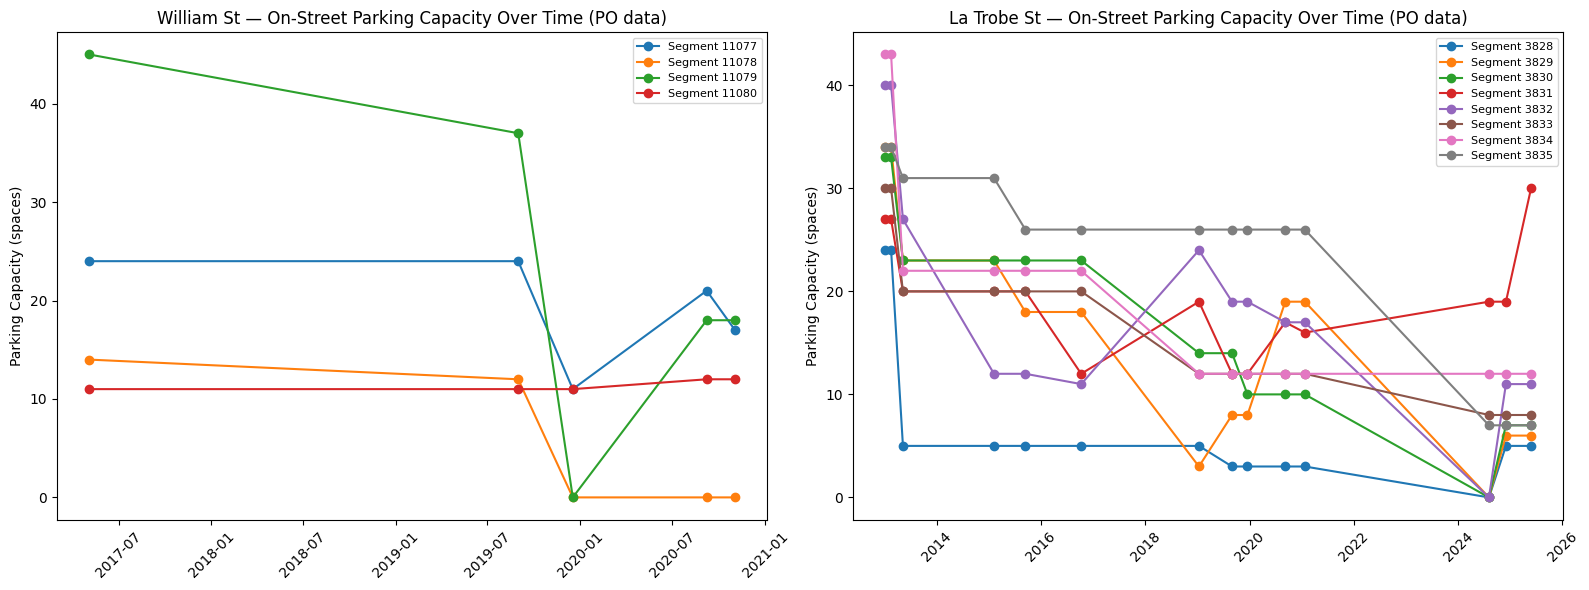

In [19]:
def parse_po_date(x):
    return pd.to_datetime(str(int(x)), format='%Y%m%d', errors='coerce')

william_po = william_po.copy()
william_po['date'] = william_po['DateOfIntervention/InitialCapture'].apply(parse_po_date)

la_trobe_po = sites_db[sites_db['StreetInScope'].str.contains('LA TROBE', case=False, na=False)].copy()
la_trobe_po['date'] = la_trobe_po['DateOfIntervention/InitialCapture'].apply(parse_po_date)

fig, axes = plt.subplots(1, 2, figsize=(16,6))

for seg in william_po['StreetSegmentID'].unique():
    sub = william_po[william_po['StreetSegmentID']==seg].sort_values('date')
    axes[0].plot(sub['date'], sub['StreetInScopeOnStreetParkingCapacity'], marker='o', label=f"Segment {seg}")
axes[0].set_title("William St — On-Street Parking Capacity Over Time (PO data)")
axes[0].set_ylabel("Parking Capacity (spaces)")
axes[0].legend(fontsize=8)
axes[0].tick_params(axis='x', rotation=45)

for seg in la_trobe_po['StreetSegmentID'].unique():
    sub = la_trobe_po[la_trobe_po['StreetSegmentID']==seg].sort_values('date')
    axes[1].plot(sub['date'], sub['StreetInScopeOnStreetParkingCapacity'], marker='o', label=f"Segment {seg}")
axes[1].set_title("La Trobe St — On-Street Parking Capacity Over Time (PO data)")
axes[1].set_ylabel("Parking Capacity (spaces)")
axes[1].legend(fontsize=8)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig("parking_capacity_over_time.png", dpi=150)
plt.show()


**Key finding:** Unlike `PedestrianEstimatesAvgDay` (which turned out to be a fixed, one-time number per segment, not something that changes over time), the parking capacity numbers actually do change, giving real, dated proof of how much parking was removed when each street's bike lane went in. This can't replace a pedestrian before/after, but it's still a useful, real contribution to the parking side of the project.

## 10. Key Findings Summary

1. I confirmed the Spencer St and William St sensors by checking their actual coordinates. One sensor (`Col620_T`, really called "Spencer St-Collins St (North)") got missed when I first searched by name good reminder to double-check against the official Sensor Locations dataset next time.
2. The pedestrian data only goes back to **August 2024**. This isn't just a Spencer/William St issue , it's a limit on the whole dataset.
3. Spencer St gets about **2.6x more pedestrians** than William St on average, but the more interesting part is that the two streets behave differently day to day: Spencer St stays busy on weekends, while William St is clearly commuter-driven and drops off hard on Saturday and Sunday.
4. Using the PO's `sites_db.csv` file, I confirmed Spencer St really is a **control site**, and found exact dates for when the bike lanes went in on William St (**Dec 2019 / Nov 2020**) and La Trobe St (**May 2013**). All of these happened before our pedestrian data even starts.
5. I also noticed a mismatch: a teammate used **May 2025** as La Trobe St's intervention date, but the PO data doesn't show any real change happening then. Worth flagging to the team.
6. One good find: even though pedestrian counts can't show a before/after, the **parking capacity numbers** in the PO data actually do change over time, so I could show real evidence of parking being removed for each bike lane. Not a pedestrian result, but still useful for the parking side of the project.

